In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import smplotlib
from astropy import units as u


def get_r_xy(t, a, P):
    
    theta_t = (2*np.pi / P.value) * t
    
    return np.array([np.cos(theta_t), np.sin(theta_t)]) * a

Bad value in file '/home/a268p582/anaconda3/lib/python3.10/site-packages/smplotlib/smplot.mplstyle', line 338 ('mathtext.it:  AVHershey Complex:mediumitalic'): Key mathtext.it: 
AVHershey Complex:mediumitalic
                        ^
ParseException: Expected end of text, found 'italic'  (at char 24), (line:1, col:25)


In [45]:
#Define some constants

m1 = 1*u.solMass
m2 = 1*u.jupiterMass
m3 = 1*u.earthMass

M = m1 + m2.to(u.solMass) + m3.to(u.solMass)

P2 = 12*u.year
P3 = 1*u.year

#Use Kepler's third law to get the semimajor axis
a2 = P2.value ** (2/3) *u.au
a3 = P3.value ** (2/3) *u.au

In [46]:
time = np.linspace(0,12,1000)

orbit2 = (m2.to(u.solMass)/M).value * get_r_xy(time, a2,P2)

orbit3 = (m3.to(u.solMass)/M).value * get_r_xy(time, a3,P3)

orbit =-(orbit2+orbit3)

### For a Sun-Earth-Jupiter system

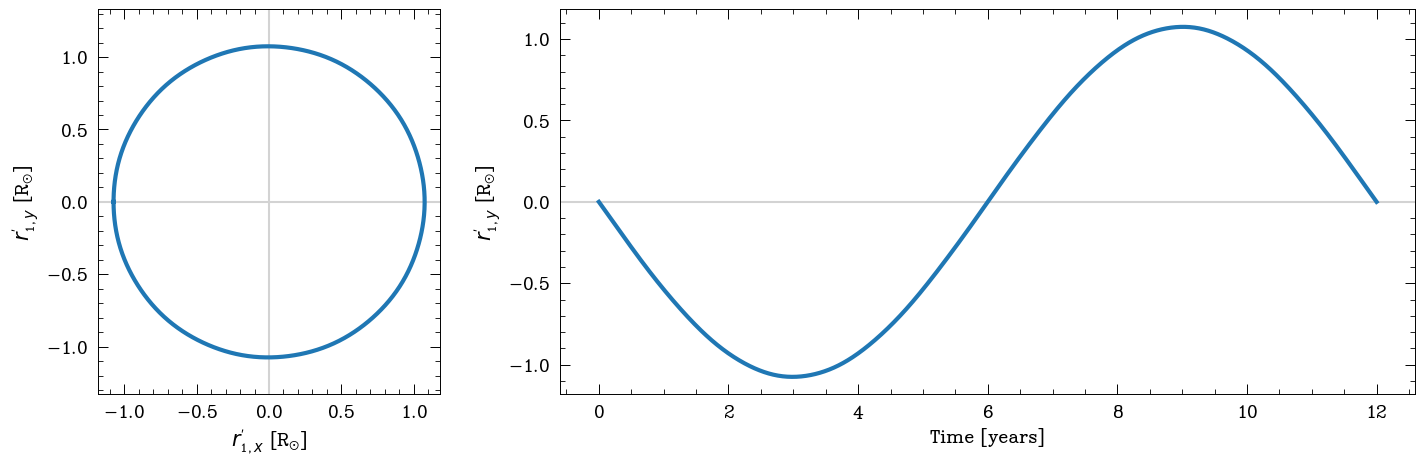

In [47]:
fig, ax = plt.subplots(figsize=(17,5),ncols=2,width_ratios=[1, 2.5])

ax[0].set_aspect('equal', adjustable='datalim')
ax[0].axvline(x=0,c='lightgrey')
ax[0].axhline(y=0,c='lightgrey')

ax[0].set_ylabel(r"$r_{1,y}^{\prime}$ [R$_{\odot}$]")
ax[0].set_xlabel(r"$r_{1,x}^{\prime}$ [R$_{\odot}$]")

ax[1].set_ylabel(r"$r_{1,y}^{\prime}$ [R$_{\odot}$]")
ax[1].set_xlabel("Time [years]")

ax[1].axhline(y=0,c='lightgrey')


ax[0].plot(orbit[0].to(u.solRad),orbit[1].to(u.solRad),lw=3)
ax[1].plot(time,orbit[1].to(u.solRad),lw=3)

### The motion of the Sun around the center of mass is effectively a circle. The Earth has too little mass compared to Jupiter to perturb the Sun in this case. What is remarkable is that, despite having less than 0.1% the mass of the Sun, Jupiter is able to pull the center of mass further than one Solar radius.

### What happens if we increase the mass of the Earth?

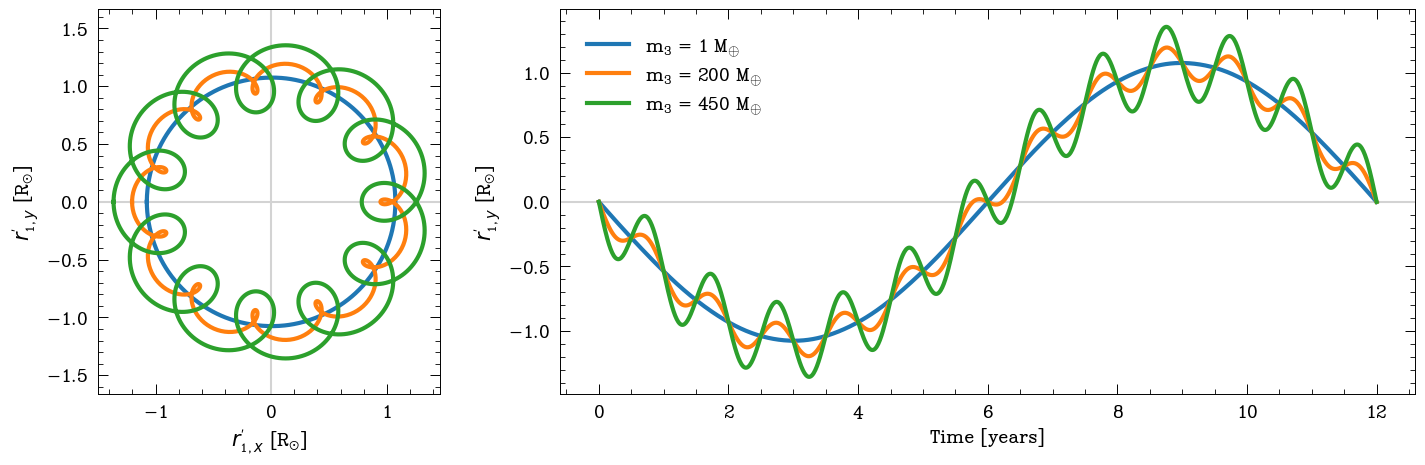

In [54]:
fig, ax = plt.subplots(figsize=(17,5),ncols=2,width_ratios=[1, 2.5])

ax[0].set_aspect('equal', adjustable='datalim')
ax[0].axvline(x=0,c='lightgrey')
ax[0].axhline(y=0,c='lightgrey')

ax[0].set_ylabel(r"$r_{1,y}^{\prime}$ [R$_{\odot}$]")
ax[0].set_xlabel(r"$r_{1,x}^{\prime}$ [R$_{\odot}$]")

ax[1].set_ylabel(r"$r_{1,y}^{\prime}$ [R$_{\odot}$]")
ax[1].set_xlabel("Time [years]")

ax[1].axhline(y=0,c='lightgrey')



for m in [1,200,450]:
    
    m3 = m*u.earthMass
    
    M =  m1 + m2.to(u.solMass) + m3.to(u.solMass)
    
    orbit3 = (m3.to(u.solMass)/M).value * get_r_xy(time, a3,P3)
    orbit2 = (m2.to(u.solMass)/M).value * get_r_xy(time, a2,P2)

    orbit = -(orbit2+orbit3)
    
    ax[0].plot(orbit[0].to(u.solRad),orbit[1].to(u.solRad),label=rf'm$_3$ = {m}'+r' M$_{\oplus}$',lw=3)
    ax[1].plot(time,orbit[1].to(u.solRad),label=rf'm$_3$ = {m}'+r' M$_{\oplus}$',lw=3)
ax[1].legend()

### As we increase the mass of Earth, we begin to see a greater influence on the motion of the Sun around the COM.  Since the orbital period is shorter than Jupiter, this is imprinted on the circular motion caused by Jupiter

### Now we replace Earth with Saturn

In [62]:
m1 = 1*u.solMass
m2 = 1*u.jupiterMass
m3 = 0.299*u.jupiterMass

M = m1 + m2.to(u.solMass) + m3.to(u.solMass)

P2 = 12*u.year
P3 = 30*u.year

#Use Kepler's third law to get the semimajor axis
a2 = P2.value ** (2/3) *u.au
a3 = P3.value ** (2/3) *u.au

time = np.linspace(0,500,1000)

orbit2 = (m2.to(u.solMass)/M).value * get_r_xy(time, a2,P2)

orbit3 = (m3.to(u.solMass)/M).value * get_r_xy(time, a3,P3)


orbit =-(orbit2+orbit3)


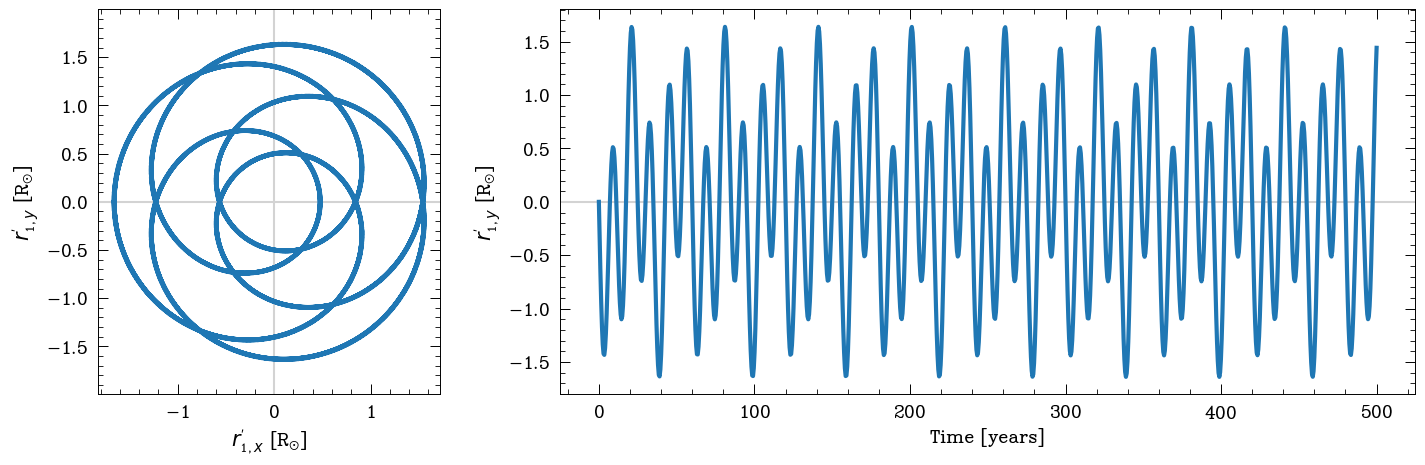

In [63]:
fig, ax = plt.subplots(figsize=(17,5),ncols=2,width_ratios=[1, 2.5])

ax[0].set_aspect('equal', adjustable='datalim')
ax[0].axvline(x=0,c='lightgrey')
ax[0].axhline(y=0,c='lightgrey')

ax[0].set_ylabel(r"$r_{1,y}^{\prime}$ [R$_{\odot}$]")
ax[0].set_xlabel(r"$r_{1,x}^{\prime}$ [R$_{\odot}$]")

ax[1].set_ylabel(r"$r_{1,y}^{\prime}$ [R$_{\odot}$]")
ax[1].set_xlabel("Time [years]")

ax[1].axhline(y=0,c='lightgrey')


ax[0].plot(orbit[0].to(u.solRad),orbit[1].to(u.solRad),lw=3)
ax[1].plot(time,orbit[1].to(u.solRad),lw=3)

### Adding Saturn creates more complex motion, and increases the maximum deviation the Sun has from the COM.